# ClinVar Pathogenicity Analysis

This notebook compares pathogenic and benign ClinVar variants and explores whether simple features can help distinguish between them.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

print("ok")

ok


In [ ]:
import pandas as pd

# ladataan ClinVar-data
df = pd.read_csv("../../data/variant_summary.txt.gz", sep="\t")

df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_2760\2585408529.py:4: DtypeWarning: Columns (0: Chromosome) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../../data/variant_summary.txt.gz", sep="\t")


,#AlleleID,Type,Name,GeneID,GeneSymbol,HGNC_ID,ClinicalSignificance,ClinSigSimple,LastEvaluated,RS# (dbSNP),...,AlternateAlleleVCF,SomaticClinicalImpact,SomaticClinicalImpactLastEvaluated,ReviewStatusClinicalImpact,Oncogenicity,OncogenicityLastEvaluated,ReviewStatusOncogenicity,SCVsForAggregateGermlineClassification,SCVsForAggregateSomaticClinicalImpact,SCVsForAggregateOncogenicityClassification
0,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
1,15041,Indel,NM_014855.3(AP5Z1):c.80_83delinsTGCTGTAAACTGTA...,9907,AP5Z1,HGNC:22197,Pathogenic/Likely pathogenic,1,"Dec 17, 2024",397704705,...,TGCTGTAAACTGTAACTGTAAA,-,-,-,-,-,-,SCV001451119|SCV005622007|SCV005909190,-,-
2,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
3,15042,Deletion,NM_014855.3(AP5Z1):c.1413_1426del (p.Leu473fs),9907,AP5Z1,HGNC:22197,Pathogenic,1,"Jun 29, 2010",397704709,...,G,-,-,-,-,-,-,SCV000020156,-,-
4,15043,single nucleotide variant,NM_014630.3(ZNF592):c.3136G>A (p.Gly1046Arg),9640,ZNF592,HGNC:28986,Uncertain significance,0,"Jun 29, 2015",150829393,...,A,-,-,-,-,-,-,SCV000020157,-,-


In [ ]:
df.shape

(8918806, 43)

In [ ]:
df.shape

(8918806, 43)

In [ ]:
pathogenic = df[df["ClinicalSignificance"].str.contains("Pathogenic", na=False)]
benign = df[df["ClinicalSignificance"].str.contains("Benign", na=False)]

In [ ]:
print("Pathogenic:", len(pathogenic))
print("Benign:", len(benign))

Pathogenic: 481660
Benign: 554593


In [ ]:
pathogenic_genes = pathogenic["GeneSymbol"].value_counts().head(10)
benign_genes = benign["GeneSymbol"].value_counts().head(10)

pathogenic_genes

GeneSymbol
BRCA2    10742
NF1       9914
BRCA1     8285
ATM       6468
FBN1      5042
APC       4753
DMD       4749
MSH6      4121
MSH2      3980
MLH1      3326
Name: count, dtype: int64

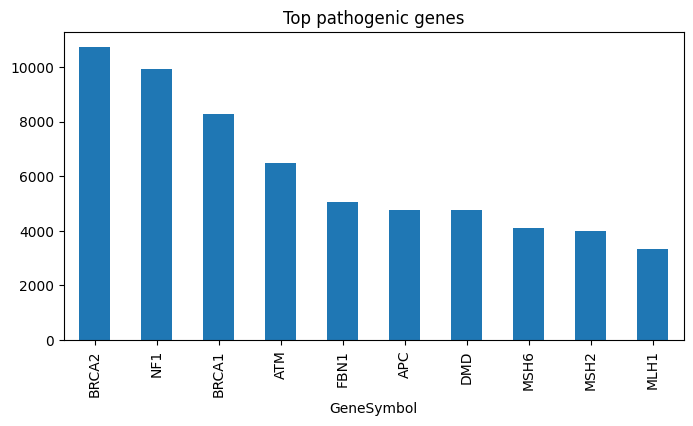

In [ ]:
import matplotlib.pyplot as plt
import os

os.makedirs("../figures", exist_ok=True)

pathogenic_genes.plot(kind="bar", figsize=(8, 4))
plt.title("Top pathogenic genes")
plt.savefig("../figures/clinvar_top_genes.png")
plt.show()

In [ ]:
pathogenic_genes / pathogenic_genes.sum()

GeneSymbol
BRCA2    0.175008
NF1      0.161518
BRCA1    0.134979
ATM      0.105376
FBN1     0.082144
APC      0.077436
DMD      0.077370
MSH6     0.067139
MSH2     0.064842
MLH1     0.054187
Name: count, dtype: float64

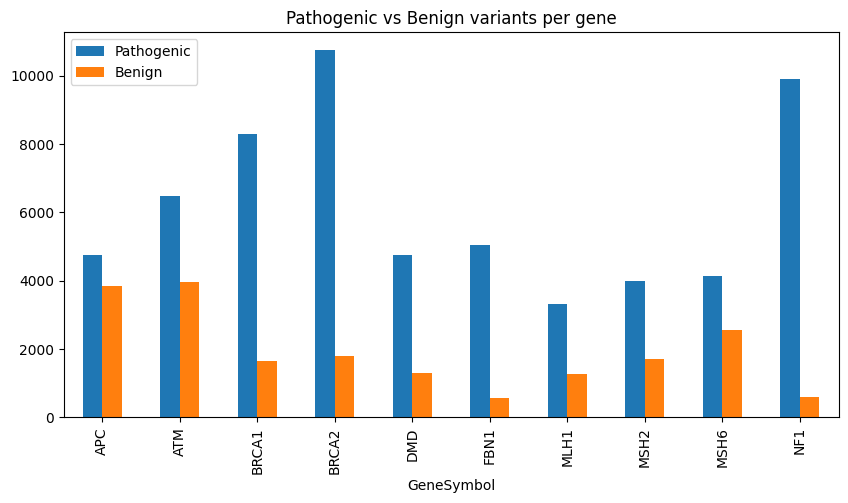

In [ ]:
import matplotlib.pyplot as plt

top_genes = pathogenic_genes.head(10).index

path_counts = pathogenic[pathogenic["GeneSymbol"].isin(top_genes)]["GeneSymbol"].value_counts()
benign_counts = benign[benign["GeneSymbol"].isin(top_genes)]["GeneSymbol"].value_counts()

df_compare = pd.DataFrame({
    "Pathogenic": path_counts,
    "Benign": benign_counts
}).fillna(0)

df_compare.plot(kind="bar", figsize=(10,5))
plt.title("Pathogenic vs Benign variants per gene")
plt.show()


<Axes: xlabel='GeneSymbol'>

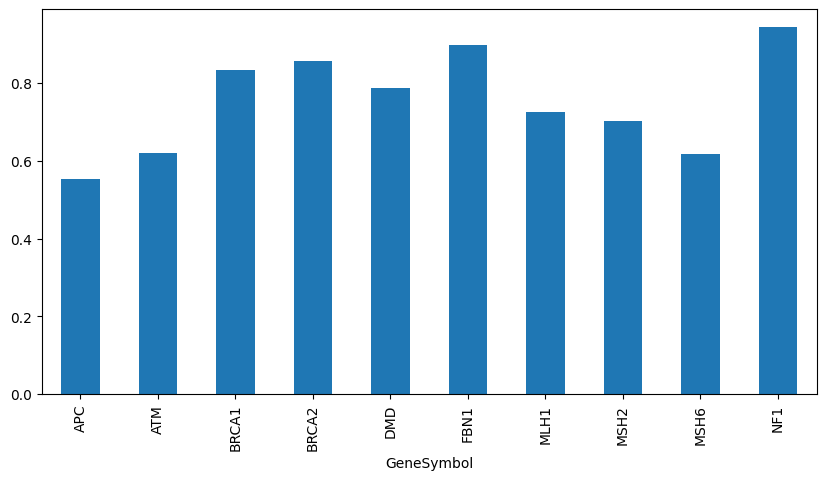

In [ ]:
df_compare["ratio"] = df_compare["Pathogenic"] / (df_compare["Pathogenic"] + df_compare["Benign"])
df_compare["ratio"].plot(kind="bar", figsize=(10,5))

In [ ]:
import os
os.makedirs("../figures", exist_ok=True)

df_compare["ratio"] = df_compare["Pathogenic"] / (
    df_compare["Pathogenic"] + df_compare["Benign"]
)

df_compare["ratio"].plot(kind="bar", figsize=(8,4))
plt.title("Pathogenic variant ratio per gene")

plt.savefig("../figures/clinvar_pathogenic_ratio.png")

plt.show()